Imports

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

Loading the Dataset

In [52]:
data = pd.read_csv('e-commerceData-kmeans-clusterng.csv', delimiter=',', encoding='ISO-8859-1')

EDA

In [53]:
#data.head()
#data.info()
#data.describe().T
data.isnull().sum()
data.shape

(541909, 8)

preprocesing

In [54]:
data.dropna(inplace=True)
data.isnull().sum()
data.shape
data['Quantity'] > 0
data = data[data['Quantity'] > 0]
data[data['UnitPrice']<0].shape[0]
data.drop(data[data['Quantity'] < 0].index, inplace=True)

Feature Engineering

In [55]:
data['Sales'] = data['Quantity'] * data['UnitPrice']
new_data = data.groupby('CustomerID')['Sales'].sum().reset_index()
new_data
num_trans = data.groupby('CustomerID')['InvoiceNo'].count().reset_index()
num_trans

,CustomerID,InvoiceNo
0,12346.0,1
1,12347.0,182
2,12348.0,31
3,12349.0,73
4,12350.0,17
...,...,...
4334,18280.0,10
4335,18281.0,7
4336,18282.0,12
4337,18283.0,756


In [56]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
data['Last Transaction'] = (data['InvoiceDate'].max() - data['InvoiceDate']).dt.days
lt = data.groupby(['CustomerID', 'Country'])['Last Transaction'].max().reset_index()
merge_table = pd.merge(lt, num_trans, how='inner', on='CustomerID')
new_df = pd.merge(merge_table, new_data, how='inner', on='CustomerID')
print(lt)
print(new_df)

      CustomerID         Country  Last Transaction
0        12346.0  United Kingdom               325
1        12347.0         Iceland               366
2        12348.0         Finland               357
3        12349.0           Italy                18
4        12350.0          Norway               309
...          ...             ...               ...
4342     18280.0  United Kingdom               277
4343     18281.0  United Kingdom               180
4344     18282.0  United Kingdom               125
4345     18283.0  United Kingdom               336
4346     18287.0  United Kingdom               201

[4347 rows x 3 columns]
      CustomerID         Country  Last Transaction  InvoiceNo     Sales
0        12346.0  United Kingdom               325          1  77183.60
1        12347.0         Iceland               366        182   4310.00
2        12348.0         Finland               357         31   1797.24
3        12349.0           Italy                18         73   1757.55
4  

Removing Outlier

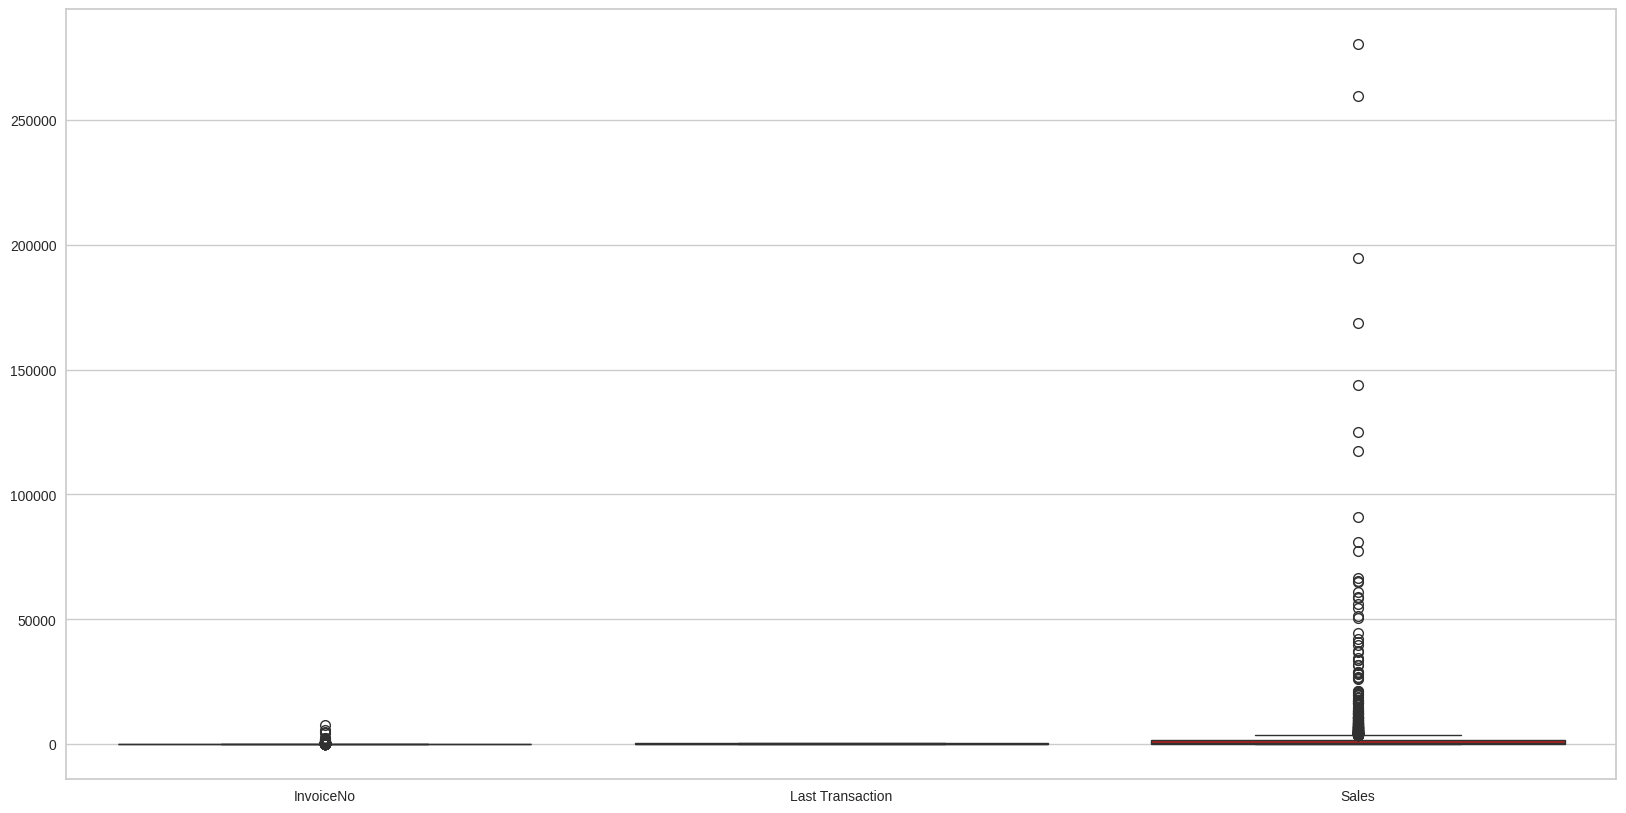

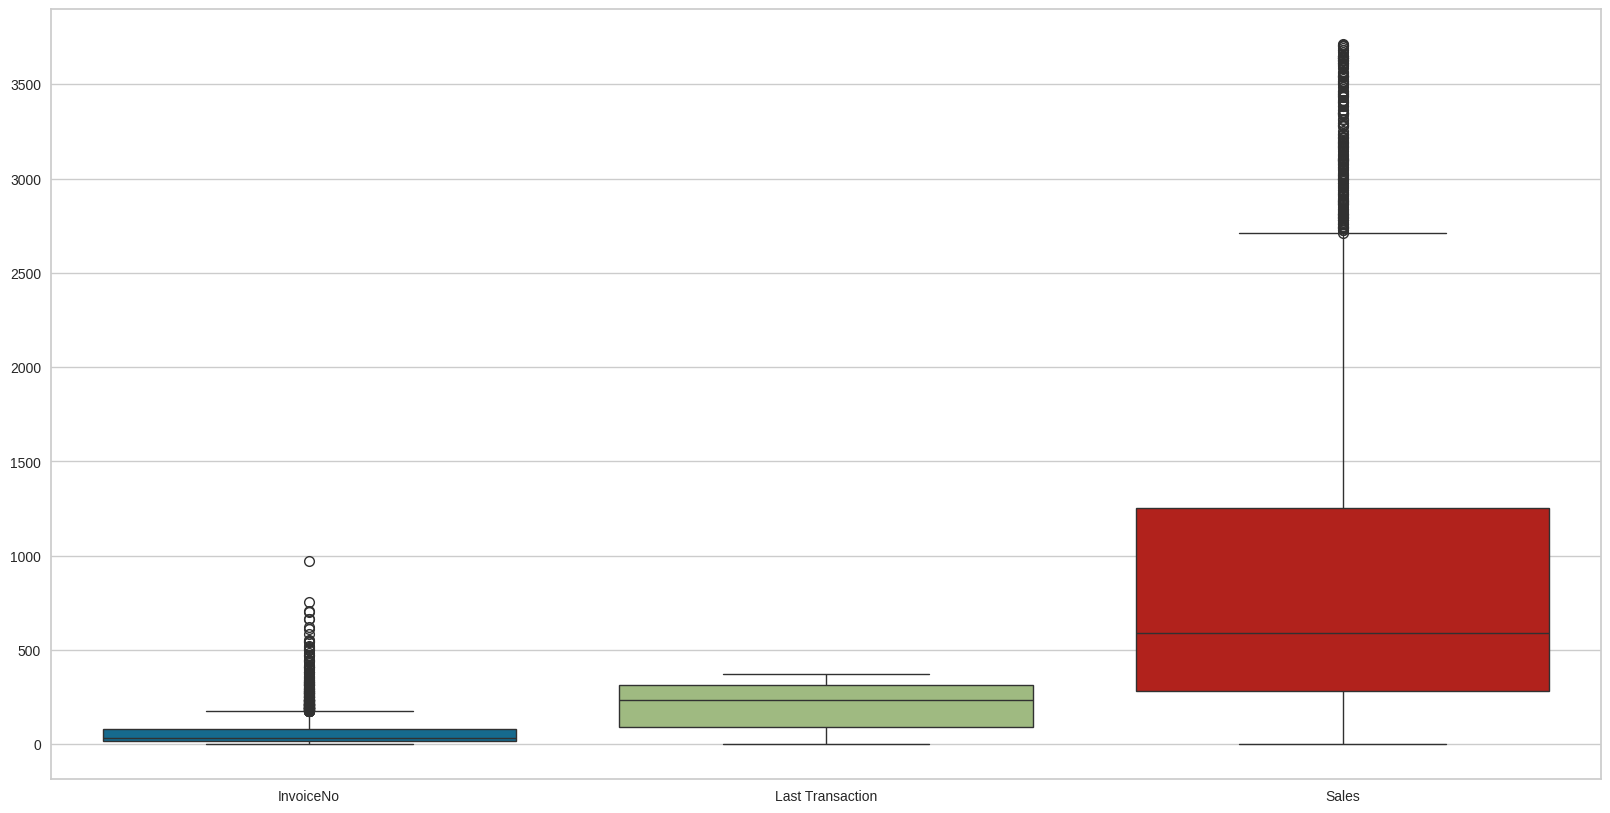

In [57]:
plt.figure(figsize=(20, 10))
sns.boxplot(data=new_df[['InvoiceNo', 'Last Transaction', 'Sales']])
plt.show()

IQR = new_df['Sales'].quantile(0.75) - new_df['Sales'].quantile(0.25)
lower_limit = new_df['Sales'].quantile(0.25) - 1.5 * IQR
upper_limit = new_df['Sales'].quantile(0.75) + 1.5 * IQR
new_df_iqr = new_df[(new_df['Sales'] < upper_limit) & (new_df['Sales'] > lower_limit)]

plt.figure(figsize=(20, 10))
sns.boxplot(data=new_df_iqr[['InvoiceNo', 'Last Transaction', 'Sales']])
plt.show()

data scalling

In [58]:
from sklearn.preprocessing import MinMaxScaler
new2_df= new_df_iqr[['Last Transaction','InvoiceNo','Sales']]
scaler = MinMaxScaler()
scaled_df = scaler.fit_transform(new2_df)
scaled_df = pd.DataFrame(scaled_df)
scaled_df.columns = ['Last Transaction','InvoiceNo','Sales']
scaled_df['Country'] = new_df_iqr['Country']
scaled_df
df_k=scaled_df.drop(columns=['Country'],axis=1)

k-means model training

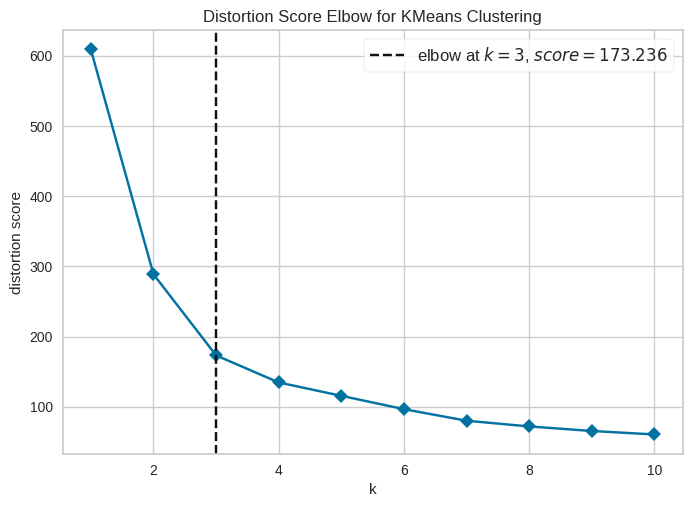

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [59]:
from yellowbrick.cluster import KElbowVisualizer
model = KMeans()

visualizer = KElbowVisualizer(model, k=(1,11), timings= False)
visualizer.fit(df_k)
visualizer.show()

model evaluation

In [60]:
from sklearn.metrics import silhouette_samples, silhouette_score
score = silhouette_score(df_k, model.labels_, metric='euclidean')
print(score)

0.37291163600834554
